****SVM****

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Importing the dataset
X = pd.read_csv('D:/sgk62/Documents/Master of AI/AML/Assignment Data/X_preprocessed_10K_RemovedMorefeature_1.csv')
y = pd.read_csv('D:/sgk62/Documents/Master of AI/AML/Assignment Data/y_preprocessed_10K_RemovedMorefeature_1.csv')

In [3]:
# Check type
if isinstance(y, pd.Series):
    print("y is a Series")
elif isinstance(y, pd.DataFrame):
    print("y is a DataFrame")
else:
    print("y is neither a Series nor a DataFrame")

y is a DataFrame


In [4]:
# Convert the DataFrame to a Series
y= y.squeeze()

In [5]:
y

0        1
1        1
2        0
3        0
4        2
        ..
20905    2
20906    2
20907    2
20908    2
20909    2
Name: IncidentGrade, Length: 20910, dtype: int64

In [6]:
print(y.head())

0    1
1    1
2    0
3    0
4    2
Name: IncidentGrade, dtype: int64


In [7]:
# Data split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 1)

Linear Kernel

In [8]:
svclassifier = SVC(kernel='linear', gamma='scale')
svclassifier.fit(X_train, y_train)

SVC(kernel='linear')

In [9]:
y_pred_lnr = svclassifier.predict(X_test)

In [10]:
y_pred_lnr

array([2, 0, 2, ..., 1, 2, 1])

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print("Linear Kernal of SVC")
print("Accuracy = ", accuracy_score(y_test, y_pred_lnr))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lnr))
print("\nClassification Report")
print(classification_report(y_test, y_pred_lnr))

Linear Kernal of SVC
Accuracy =  0.5968436154949784

Confusion Matrix
[[798 413 183]
 [459 730 164]
 [250 217 968]]

Classification Report
              precision    recall  f1-score   support

           0       0.53      0.57      0.55      1394
           1       0.54      0.54      0.54      1353
           2       0.74      0.67      0.70      1435

    accuracy                           0.60      4182
   macro avg       0.60      0.60      0.60      4182
weighted avg       0.60      0.60      0.60      4182



Polynomial Kernel

In [12]:
svclassifier = SVC(kernel='poly', degree=8, gamma='scale')
svclassifier.fit(X_train, y_train)

SVC(degree=8, kernel='poly')

In [13]:
y_pred_poly = svclassifier.predict(X_test)

In [14]:
y_pred_poly

array([2, 0, 2, ..., 1, 2, 2])

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print("Polynomial Kernal of SVC")
print("Accuracy = ", accuracy_score(y_test, y_pred_poly))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_poly))
print("\nClassification Report")
print(classification_report(y_test, y_pred_poly))

Polynomial Kernal of SVC
Accuracy =  0.7467718794835008

Confusion Matrix
[[1058  202  134]
 [ 285  999   69]
 [ 270   99 1066]]

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.76      0.70      1394
           1       0.77      0.74      0.75      1353
           2       0.84      0.74      0.79      1435

    accuracy                           0.75      4182
   macro avg       0.75      0.75      0.75      4182
weighted avg       0.76      0.75      0.75      4182



RBF Kernel

In [16]:
svclassifier = SVC(kernel='rbf', gamma='scale')
svclassifier.fit(X_train, y_train)

SVC()

In [17]:
y_pred_rbf = svclassifier.predict(X_test)

In [18]:
y_pred_rbf

array([2, 1, 2, ..., 1, 2, 1])

In [19]:
print("RBF Kernal of SVC")
print("Accuracy = ", accuracy_score(y_test, y_pred_rbf))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rbf))
print("\nClassification Report")
print(classification_report(y_test, y_pred_rbf))

RBF Kernal of SVC
Accuracy =  0.664753706360593

Confusion Matrix
[[1004  277  113]
 [ 452  819   82]
 [ 321  157  957]]

Classification Report
              precision    recall  f1-score   support

           0       0.56      0.72      0.63      1394
           1       0.65      0.61      0.63      1353
           2       0.83      0.67      0.74      1435

    accuracy                           0.66      4182
   macro avg       0.68      0.66      0.67      4182
weighted avg       0.68      0.66      0.67      4182



Sigmoid Kernel

In [20]:
# Using Sigmoid Kernel
svclassifier = SVC(kernel='sigmoid', gamma='scale')
svclassifier.fit(X_train, y_train)

SVC(kernel='sigmoid')

In [21]:
y_pred_sig = svclassifier.predict(X_test)

In [22]:
y_pred_sig

array([2, 2, 0, ..., 0, 0, 2])

In [23]:
print("Sigmoid Kernal of SVC")
print("Accuracy = ", accuracy_score(y_test, y_pred_sig))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_sig))
print("\nClassification Report")
print(classification_report(y_test, y_pred_sig))

Sigmoid Kernal of SVC
Accuracy =  0.28072692491630796

Confusion Matrix
[[622  47 725]
 [674  34 645]
 [906  11 518]]

Classification Report
              precision    recall  f1-score   support

           0       0.28      0.45      0.35      1394
           1       0.37      0.03      0.05      1353
           2       0.27      0.36      0.31      1435

    accuracy                           0.28      4182
   macro avg       0.31      0.28      0.23      4182
weighted avg       0.31      0.28      0.24      4182



Randomized Search CV

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from numpy import arange
from scipy.stats import uniform
from sklearn.metrics import confusion_matrix

model_svc = SVC()

parameters = {
    'kernel': ['poly'],  # Removed sigmoid, RFL and Linear as the performance is very poor as Poly is much higher than the rest
    'C': uniform(loc=1, scale=500),  # Using uniform distribution for continuous parameters, changed from 999 to 500
    'gamma': uniform(loc=1e-4, scale=0.1), 
    'degree': arange(1, 10, 1),
    'class_weight': ['balanced'],
    'random_state': arange(1, 10, 1)
}

# Building Randomized Search algorithm with cross-validation and accuracy score.
random_search_svc = RandomizedSearchCV(estimator=model_svc, param_distributions=parameters, scoring='accuracy', cv=5, n_jobs=-1, n_iter=50) # change n_iter from 100 to 50

random_search_svc.fit(X_train, y_train)
best_parameters_svc = random_search_svc.best_params_
best_score_svc = random_search_svc.best_score_
print("Best Parameters:", best_parameters_svc)
print("Best Score:", best_score_svc)

y_pred = random_search_svc.predict(X_test)

# Get the accuracy score
svc_acc = accuracy_score(y_test, y_pred) * 100
svc_pre = precision_score(y_test, y_pred, average='micro')
svc_recall = recall_score(y_test, y_pred, average='micro')
svc_f1_micro = f1_score(y_test, y_pred, average='micro')
svc_f1_macro = f1_score(y_test, y_pred, average='macro')

Best Parameters: {'C': np.float64(433.49631192577095), 'class_weight': 'balanced', 'degree': np.int64(9), 'gamma': np.float64(0.09889243139274681), 'kernel': 'poly', 'random_state': np.int64(6)}
Best Score: 0.7492234084470045


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.77      0.71      1394
           1       0.77      0.74      0.76      1353
           2       0.84      0.75      0.79      1435

    accuracy                           0.75      4182
   macro avg       0.76      0.75      0.75      4182
weighted avg       0.76      0.75      0.75      4182



In [31]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

print("SVM - Accuracy: {:.3f}%".format(svc_acc))
print("SVM - Precision: {:.3f}".format(svc_pre))
print("SVM - Recall: {:.3f}".format(svc_recall))
print("SVM - F1 Score (Micro): {:.3f}".format(svc_f1_micro))
print("SVM - F1 Score (Macro): {:.3f}".format(svc_f1_macro))
print("Confusion Matrix:\n", conf_matrix)

SVM - Accuracy: 75.227%
SVM - Precision: 0.752
SVM - Recall: 0.752
SVM - F1 Score (Micro): 0.752
SVM - F1 Score (Macro): 0.754
Confusion Matrix:
 [[1068  198  128]
 [ 279 1004   70]
 [ 262   99 1074]]


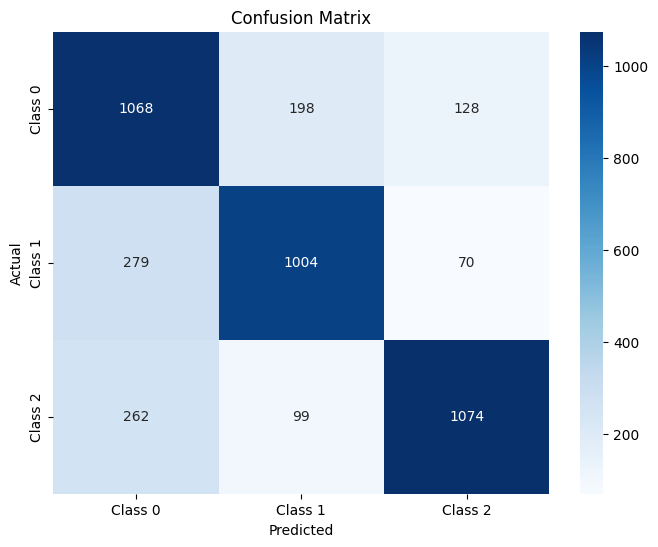

In [33]:
import seaborn as sns
# Generate and plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()